##**Quantum Chemistry Coding for PolyhaQ Event (part 1)! Let's Go!**




<center>
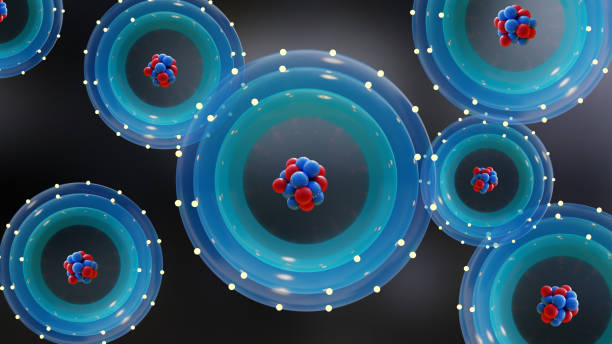
</center>
Reference of Image: www.istockphoto.com

**Animation of the Quantum Fourier Transform (QFT) on the Bloch Sphere:**

https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-fourier-transform.ipynb

##**Two hands-on exercises on the Quantum Fourier Transform and Quantum Phase Estimation algorithms**

##**The exercise 7.32 from Thomas G. Wong's book: Introduction to classical and quantum computing (Wong, Thomas G. Introduction to classical and quantum computing. Omaha, Nebraska: Rooted Grove, 2022.).**

Insert the IQFT circuit in the space provided, and verify that it cancels out the QFT gate that is alreadypresent, so the qubits are unchanged. Use single-qubit gates and controls to construct the circuit, not the $QFT^\dagger$ gate that comes with Quirk. Also, note $R_4^\dagger = Z^{-1/8}$, and this can be made with the“Formula Z Rotation” in Quirk, which has a label $Z^{f(t)}$.

Answer:

In [ ]:
from IPython.display import IFrame

url = "https://algassert.com/quirk#circuit={%22cols%22:[[%22QFT4%22]],%22gates%22:[{%22id%22:%22~e1s1%22,%22name%22:%22Reverse%22,%22circuit%22:{%22cols%22:[[%22QFT4%22]]}}]}"
IFrame(url, width=1000, height=600)

To undo a quantum circuit, reverse the order of the gates and replace each gate by its inverse.

---

The circuit already contains a $QFT_{4}$ block:

$$ |x\rangle \xrightarrow{QFT_{4}} QFT_{4} ∣x⟩$$

---

We must append gates that perform $QFT_{4}^\dagger$. So that


$$QFT_{4}^\dagger QFT_{4}= I.$$

---


Note
$$R_k =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i / 2^k}
\end{pmatrix}.$$

The inverse phase gates are
$$R_{k}^{\dagger} =
\begin{pmatrix}
1 & 0 \\
0 & e^{-2\pi i / 2^k}
\end{pmatrix}.$$

---

The 4-qubit QFT is built from:

First qubit:

$$H_{0}$$
	​

then, controlled phase rotations:
$$CR_{2} (1 → 0),$$
$$CR_{3}(2 → 0),$$
$$CR_{4}(3 → 0).$$

---

Second qubit:

$$H_{1}$$
	​
then,
$$CR_{2} (2 → 1),$$
$$CR_{3}(3 → 1).$$

---

Third qubit:

$$H_{2}$$
then,
$$CR_{2} (3 → 2).$$

---

Fourth qubit:
$$H_{3}.$$

---

Final swaps

Swap top and bottom qubits:

$$SWAP(0,3),$$
$$SWAP(1,2).$$

---

**For applying IQFT,**

First:
we should undo the last two SWAP gates.
Fortunately,
$$SWAP^{−1}=SWAP.$$

So immediately after the QFT block, the ISWAPs inverse the SWAPs in QFT.
Undo the last Hadamard

---

Second:

Undo $H_{3}$ gate.

---

Third:
Undo the third step in QFT:
$$CR_{2}^{\dagger}(3→2),$$
$$H_{2}.$$

---

Forth:

Undo the second step in QFT:


Note

$$R_{2}^{\dagger}=Z^{-1/2}.$$

So,

$$CR_{3}^{\dagger}(3→1),$$
$$CR_{2}^{\dagger}(2→1),$$
$$H_{1}.$$

---

Fifth:

Undo the first step in QFT:


Note
$$R_{3}^{\dagger}=Z^{-1/4}.$$

So,

$$CR_{4}^{\dagger}(3→0),$$
$$CR_{3}^{\dagger}(2→0),$$
$$CR_{2}^{\dagger}(1→0),$$
$$H_{0}.$$

In [ ]:
from IPython.display import IFrame

url = "https://algassert.com/quirk#circuit=%7b%22cols%22:[[%22QFT4%22],[%22rev4%22],[%22H%22],[%22%e2%80%a2%22,%22Z%5e-%c2%bd%22],[1,%22H%22],[%22%e2%80%a2%22,1,%22Z%5e-%c2%bc%22],[1,%22%e2%80%a2%22,%22Z%5e-%c2%bd%22],[1,1,%22H%22],[%22%e2%80%a2%22,1,1,%7b%22id%22:%22Z%5eft%22,%22arg%22:%22-1/8%22%7d],[1,%22%e2%80%a2%22,1,%22Z%5e-%c2%bc%22],[1,1,%22%e2%80%a2%22,%22Z%5e-%c2%bd%22],[1,1,1,%22H%22]]%7d"
IFrame(url, width=1000, height=600)

In [ ]:
!pip install qiskit
from qiskit import QuantumCircuit
from numpy import pi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.8 MB/s eta 0:00:00


**Representation of IQFT with Qiskit!**

In [ ]:
def iqft_4():
    qc = QuantumCircuit(4)

    # Undo bit reversal
    qc.swap(0, 3)
    qc.swap(1, 2)

    # q3
    qc.h(3)

    # q2
    qc.cp(-pi/2, 3, 2)      # R2†
    qc.h(2)

    # q1
    qc.cp(-pi/4, 3, 1)      # R3†
    qc.cp(-pi/2, 2, 1)      # R2†
    qc.h(1)

    # q0
    qc.cp(-pi/8, 3, 0)      # R4†
    qc.cp(-pi/4, 2, 0)      # R3†
    qc.cp(-pi/2, 1, 0)      # R2†
    qc.h(0)

    return qc

iqft = iqft_4()
print(iqft.draw())

                                                                         »
q_0: ─X──────────────────────────────────────────■──────────────■────────»
      │                                          │        ┌───┐ │        »
q_1: ─┼───X──────────────────■─────────■─────────┼────────┤ H ├─┼────────»
      │   │            ┌───┐ │         │P(-π/2)  │        └───┘ │P(-π/4) »
q_2: ─┼───X───■────────┤ H ├─┼─────────■─────────┼──────────────■────────»
      │ ┌───┐ │P(-π/2) └───┘ │P(-π/4)            │P(-π/8)                »
q_3: ─X─┤ H ├─■──────────────■───────────────────■───────────────────────»
        └───┘                                                            »
«               ┌───┐
«q_0: ─■────────┤ H ├
«      │P(-π/2) └───┘
«q_1: ─■─────────────
«                    
«q_2: ───────────────
«                    
«q_3: ───────────────
«                    


**Representation of**

$$QFT_{4}^\dagger QFT_{4}= I.$$

**with Qiskit!**

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

def qft_4():
    qc = QuantumCircuit(4)

    # q0
    qc.h(0)
    qc.cp(pi/2, 1, 0)
    qc.cp(pi/4, 2, 0)
    qc.cp(pi/8, 3, 0)

    # q1
    qc.h(1)
    qc.cp(pi/2, 2, 1)
    qc.cp(pi/4, 3, 1)

    # q2
    qc.h(2)
    qc.cp(pi/2, 3, 2)

    # q3
    qc.h(3)

    # Bit reversal
    qc.swap(0, 3)
    qc.swap(1, 2)

    return qc

qc = QuantumCircuit(4)

qc.compose(qft_4(), inplace=True)
qc.compose(iqft_4(), inplace=True)

print(qc.draw())

     ┌───┐                                                                     »
q_0: ┤ H ├─■────────■─────────────■────────────────────────────────────────────»
     └───┘ │P(π/2)  │       ┌───┐ │                                            »
q_1: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X──»
                    │P(π/4) └───┘ │        │P(π/2)  │       ┌───┐           │  »
q_2: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X──»
                                  │P(π/8)           │P(π/4) └───┘ │P(π/2) ┌───┐»
q_3: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├»
                                                                          └───┘»
«                                                                     »
«q_0: ─X─────X──────────────────────────────────────────■─────────────»
«      │     │                                          │        ┌───┐»
«q_1: ─┼──X──┼──────────────────────■─────────■────────

**Check it!**

In [ ]:
from qiskit.quantum_info import Operator
import numpy as np

U = Operator(qc).data

print(np.allclose(U, np.eye(16)))

True


##**The exercise 7.36 from Thomas G. Wong's book: Introduction to classical and quantum computing (Wong, Thomas G. Introduction to classical and quantum computing. Omaha, Nebraska: Rooted Grove, 2022.).**

There are two custom three-qubit gates, $v$ and $U$. The $v$ gate turns $|000⟩$ into $|v⟩$, which is an eigenstate of $U$ whose eigenvalue we want to estimate to $m=8$ bits. The beginning of the phase estimation circuit has been started for you.

---

(a) Using two copies of $U$, use Quirk’s “Make Gate” “FromCircuit”to create the gate $U^{2}$. Then using two copies of $U^{2}$, make $U^{4}$. Continuing, make $U^{8}$, $U^{16}$, $U^{32}$, $U^{64}$, and $U^{128}$.

---

(b) Fill in the rest of the phase estimation circuit. Hint: Use Quirk’s IQFT function, which is called $QFT^{\dagger}$, rather than constructing it froms cratch.

---

(c) What is $j=0.j_{1}j_{2}...j_{7}$ as a binary number?

---

(d) What is $j$ as a decimal number?

---

(e) What is $θ$, the phase of the eigenvalue $e^{iθ}$?

---

(f) What is the eigenvalue $e^{iθ}$?

---

(g) Explain why your value for $e^{iθ}$ is only an estimate and the actual value maybe slightly different.


**Answer:**

Since $∣v⟩$ is an eigenstate,
$$U∣v⟩=e^{iθ} ∣v⟩.$$

---

The QPE circuit estimates the phase $ϕ=\frac{θ}{2\pi},$ where

$$e^{iθ}=e^{2\pi iϕ}.$$

---

The $8$ control qubits determine the binary digits of $ϕ$.

---

**Now, we are going to solve the problem, step by step:**

(a) Construct $U^{2}$, $U^{4}$, $U^{8}$, ..., $U^{128}$

Using Quirk's Make Gate → From Circuit:

Create a circuit containing two copies of $U$. Convert it into a custom gate Name it $U^{2}.$

Since
$$U^{2}=U.U,$$

this gate applies $U$ twice.

Then repeat:

$$U^{4}=(U^{2})^{2},$$
$$U^{8}=(U^{4})^{2},$$
$$U^{16}=(U^{8})^{2},$$
$$U^{32}=(U^{16})^{2},$$
$$U^{64}=(U^{32})^{2},$$
$$U^{128}=(U^{2})^{64}.$$

These gates are then controlled by the eight ancilla qubits.

---

(b) Complete the QPE circuit

After the Hadamard gates, apply the controlled powers:

Top qubit:

$$CU^{128}$$

Next:

$$CU^{64}$$

Next:

$$CU^{32}$$

Next:

$$CU^{16}$$

Next:

$$CU^{8}$$

Next:

$$CU^{4}$$

Next:

$$CU^{2}$$

Bottom ancilla:

$$CU.$$

Then, apply Quirk's built-in $QFT^{\dagger}$ to the eight control qubits.

Finally measure the eight control qubits.

---

In [ ]:
from IPython.display import IFrame

url = "https://algassert.com/quirk#circuit={%22cols%22:[[%22~5qad%22],[1,1,1,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22],[%22~40v6%22,1,1,%22%E2%80%A2%22]],%22gates%22:[{%22id%22:%22~5qad%22,%22name%22:%22v%22,%22matrix%22:%22{{-0.1659348+0.1723347i,-0.3059354+0.117323i,0.5430605+1e-7i,0.0904578-0.0392153i,-0.28134-0.1223459i,0.439569+0.085747i,-0.4006189-0.153302i,-0.0314021+0.226037i},{0.1162014-0.0778849i,0.5771226,0.3118464+0.1089071i,0.1865103+0.2429233i,-0.1307498-0.3080872i,0.185176-0.0172083i,0.2713439-0.0113528i,0.47339},{-0.0099664-0.0374069i,-0.0092639-0.2061371i,-0.3940404+0.0891421i,0.5878164,0.0230181-0.3291718i,-0.0757367-0.165897i,-0.4296209+0.1987489i,0.0818063+0.272528i},{-0.1770402-0.4156709i,-0.112666-0.0649946i,0.4393978+0.0038472i,0.1380951+0.0720098i,0.25535-0.0499565i,-0.0526583-0.4103568i,0.252029+0.3299159i,-0.362129+0.138745i},{0.0576162+0.4381863i,-0.2228761-0.5301934i,-0.0367032+0.144593i,-0.2793523+0.099767i,0.1705211+0.0213335i,0.1946061-0.3545171i,0.2074329-0.0113865i,0.232242+0.27105i},{0.1447462-0.2786163i,-0.0653929+0.0201827i,0.0413678-0.1478637i,0.067543-0.5120393i,0.610583,0.275898+0.0996062i,-0.0304317-0.209913i,0.318013+0.0379759i},{0.2419095-0.0172707i,-0.2340145+0.1458716i,-0.3420786-0.1551317i,0.1886973-0.0467553i,-0.229102-0.2498722i,0.5029909,0.4937539,-0.271915-0.0246873i},{0.6040278,0.2095438-0.2113289i,0.1867452-0.1337548i,-0.243798-0.2733685i,-0.1299441-0.2883218i,-0.2338989+0.0557964i,-0.1126599-0.0342839i,-0.325899+0.285894i}}%22},{%22id%22:%22~40v6%22,%22name%22:%22U%22,%22matrix%22:%22{{-0.0353057-0.1939355i,-0.1742264+0.2814185i,0.0540592-0.0957761i,-0.1016182+0.1133112i,-0.1408455+0.3867461i,-0.3130854-0.2011098i,0.6076389+0.0250407i,-0.3451779-0.139473i},{0.0303799+0.0400975i,0.0967122-0.1115333i,0.2822446+0.1679825i,-0.3204471-0.0799862i,0.368101+0.4035786i,0.0217499-0.188155i,0.0633214-0.2060189i,0.5207548-0.3268389i},{0.0377557+0.0770921i,0.0676394+0.1350468i,-0.4579166-0.0181934i,0.5025843-0.151724i,0.2963508-0.1321753i,-0.3546682-0.2879441i,0.1400231+0.1780931i,0.3073399-0.1562429i},{-0.4620628+0.139863i,-0.2273231-0.1920241i,-0.0186185+0.294048i,0.0794191+0.108022i,-0.0806593-0.3320961i,0.215931-0.4399707i,0.242277-0.395778i,-0.0324177+0.0147224i},{0.4703578-0.0736594i,-0.5290234-0.0909445i,0.2464867+0.0907818i,0.2147818-0.2559429i,0.3871511-0.0433637i,0.122224+0.0136371i,0.1669238-0.0666799i,-0.107758+0.3061919i},{0.0156236+0.1357472i,0.183247+0.5674349i,0.3466198+0.452271i,0.2077634+0.3068382i,0.1264481-0.1327751i,0.2245869+0.1046829i,0.0842181+0.235343i,-0.0072737-0.0787979i},{0.6348304+0.0117976i,0.2384376-0.0367457i,-0.2680071+0.1629438i,-0.3086516+0.3932083i,-0.0921675-0.201286i,-0.0629536-0.2447519i,0.1121569-0.1792649i,0.0353322+0.1776239i},{-0.1992368+0.1732098i,-0.0499794-0.2299891i,0.2931995-0.0718263i,-0.1901297+0.1979435i,0.0541004-0.2698249i,-0.4460232+0.1934668i,0.2900189+0.3056432i,0.3041139+0.3554459i}}%22}]}"
IFrame(url, width=1000, height=600)

In [ ]:
from IPython.display import IFrame

url = "https://algassert.com/quirk#circuit={%22cols%22:[[%22~5qad%22],[1,1,1,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22,%22H%22],[%22~40v6%22,1,1,%22%E2%80%A2%22],[%22~5dl5%22,1,1,1,%22%E2%80%A2%22],[%22~jlpm%22,1,1,1,1,%22%E2%80%A2%22],[%22~etas%22,1,1,1,1,1,%22%E2%80%A2%22],[%22~cto4%22,1,1,1,1,1,1,%22%E2%80%A2%22],[%22~9a3c%22,1,1,1,1,1,1,1,%22%E2%80%A2%22],[%22~lo3n%22,1,1,1,1,1,1,1,1,%22%E2%80%A2%22],[%22~3mch%22,1,1,1,1,1,1,1,1,1,%22%E2%80%A2%22],[1,1,1,%22QFT%E2%80%A08%22]],%22gates%22:[{%22id%22:%22~5qad%22,%22name%22:%22v%22,%22matrix%22:%22{{-0.1659348+0.1723347i,-0.3059354+0.117323i,0.5430605+1e-7i,0.0904578-0.0392153i,-0.28134-0.1223459i,0.439569+0.085747i,-0.4006189-0.153302i,-0.0314021+0.226037i},{0.1162014-0.0778849i,0.5771226,0.3118464+0.1089071i,0.1865103+0.2429233i,-0.1307498-0.3080872i,0.185176-0.0172083i,0.2713439-0.0113528i,0.47339},{-0.0099664-0.0374069i,-0.0092639-0.2061371i,-0.3940404+0.0891421i,0.5878164,0.0230181-0.3291718i,-0.0757367-0.165897i,-0.4296209+0.1987489i,0.0818063+0.272528i},{-0.1770402-0.4156709i,-0.112666-0.0649946i,0.4393978+0.0038472i,0.1380951+0.0720098i,0.25535-0.0499565i,-0.0526583-0.4103568i,0.252029+0.3299159i,-0.362129+0.138745i},{0.0576162+0.4381863i,-0.2228761-0.5301934i,-0.0367032+0.144593i,-0.2793523+0.099767i,0.1705211+0.0213335i,0.1946061-0.3545171i,0.2074329-0.0113865i,0.232242+0.27105i},{0.1447462-0.2786163i,-0.0653929+0.0201827i,0.0413678-0.1478637i,0.067543-0.5120393i,0.610583,0.275898+0.0996062i,-0.0304317-0.209913i,0.318013+0.0379759i},{0.2419095-0.0172707i,-0.2340145+0.1458716i,-0.3420786-0.1551317i,0.1886973-0.0467553i,-0.229102-0.2498722i,0.5029909,0.4937539,-0.271915-0.0246873i},{0.6040278,0.2095438-0.2113289i,0.1867452-0.1337548i,-0.243798-0.2733685i,-0.1299441-0.2883218i,-0.2338989+0.0557964i,-0.1126599-0.0342839i,-0.325899+0.285894i}}%22},{%22id%22:%22~40v6%22,%22name%22:%22U%22,%22matrix%22:%22{{-0.0353057-0.1939355i,-0.1742264+0.2814185i,0.0540592-0.0957761i,-0.1016182+0.1133112i,-0.1408455+0.3867461i,-0.3130854-0.2011098i,0.6076389+0.0250407i,-0.3451779-0.139473i},{0.0303799+0.0400975i,0.0967122-0.1115333i,0.2822446+0.1679825i,-0.3204471-0.0799862i,0.368101+0.4035786i,0.0217499-0.188155i,0.0633214-0.2060189i,0.5207548-0.3268389i},{0.0377557+0.0770921i,0.0676394+0.1350468i,-0.4579166-0.0181934i,0.5025843-0.151724i,0.2963508-0.1321753i,-0.3546682-0.2879441i,0.1400231+0.1780931i,0.3073399-0.1562429i},{-0.4620628+0.139863i,-0.2273231-0.1920241i,-0.0186185+0.294048i,0.0794191+0.108022i,-0.0806593-0.3320961i,0.215931-0.4399707i,0.242277-0.395778i,-0.0324177+0.0147224i},{0.4703578-0.0736594i,-0.5290234-0.0909445i,0.2464867+0.0907818i,0.2147818-0.2559429i,0.3871511-0.0433637i,0.122224+0.0136371i,0.1669238-0.0666799i,-0.107758+0.3061919i},{0.0156236+0.1357472i,0.183247+0.5674349i,0.3466198+0.452271i,0.2077634+0.3068382i,0.1264481-0.1327751i,0.2245869+0.1046829i,0.0842181+0.235343i,-0.0072737-0.0787979i},{0.6348304+0.0117976i,0.2384376-0.0367457i,-0.2680071+0.1629438i,-0.3086516+0.3932083i,-0.0921675-0.201286i,-0.0629536-0.2447519i,0.1121569-0.1792649i,0.0353322+0.1776239i},{-0.1992368+0.1732098i,-0.0499794-0.2299891i,0.2931995-0.0718263i,-0.1901297+0.1979435i,0.0541004-0.2698249i,-0.4460232+0.1934668i,0.2900189+0.3056432i,0.3041139+0.3554459i}}%22},{%22id%22:%22~5dl5%22,%22name%22:%22U2%22,%22circuit%22:{%22cols%22:[[%22~40v6%22],[%22~40v6%22]]}},{%22id%22:%22~jlpm%22,%22name%22:%22U4%22,%22circuit%22:{%22cols%22:[[%22~5dl5%22],[%22~5dl5%22]]}},{%22id%22:%22~etas%22,%22name%22:%22U8%22,%22circuit%22:{%22cols%22:[[%22~jlpm%22],[%22~jlpm%22]]}},{%22id%22:%22~cto4%22,%22name%22:%22U16%22,%22circuit%22:{%22cols%22:[[%22~etas%22],[%22~etas%22]]}},{%22id%22:%22~9a3c%22,%22name%22:%22U32%22,%22circuit%22:{%22cols%22:[[%22~cto4%22],[%22~cto4%22]]}},{%22id%22:%22~lo3n%22,%22name%22:%22U64%22,%22circuit%22:{%22cols%22:[[%22~9a3c%22],[%22~9a3c%22]]}},{%22id%22:%22~3mch%22,%22name%22:%22U128%22,%22circuit%22:{%22cols%22:[[%22~lo3n%22],[%22~lo3n%22]]}}]}"
IFrame(url, width=1000, height=600)

**Finding the phase**

(c) For finding the phase, we can proceed as following:

From part (b), we can see each control qubit has a probability of being measured as $1$.

For a measured computational basis state:

probability near 100% ⇒ bit = $1$

probability near 0% ⇒ bit = $0$

Therefore the bits are approximately

$$10111000.$$

Quirk's QFT gate uses the standard QFT convention, where the displayed qubits are in the reverse significance order compared to the binary fraction $0.j_{1}j_{2}j_{3}...$.


Therefore we reverse the bit string:

$$10111000 → 00011101.$$

Now write this as a binary fraction:

$$j=0.00011101_{2}.$$

---

(d) To convert the answer of part (c) into decimal format, we have:

$$0.00011101_{2}​=\frac{1}{16} \times 1 + \frac{1}{32} \times 1 + \frac{1}{64} \times 1 + \frac{1}{256} \times 1 ​=0.113281225.$$

---

(e) To obtain the $θ$, we have:

the eigenvalue of $U$ is written as

$$e^{iθ}=e^{2πij},$$

where $j$ is the phase estimate obtained in part (d).

From the previous answer,

$$j≈0.1133.$$

Therefore,

$$θ=2πj.$$

Substituting $j=0.1133$,

$$θ=2π(0.1133)≈0.7118 \textbf{radians}.$$

---

(f) $e^{iθ} = cos(θ) + isin(θ)$

Substituting $θ=0.7118$,

$$e^{iθ} =cos(0.7118)+isin(0.7118).$$

Evaluating:

$$cos(0.7118)≈0.7572,$$
$$sin(0.7118)≈0.6532.$$

Therefore,

$$e^{iθ}=0.7572+0.6532i.$$

---

(g) The value of $e^{iθ}$ is only an estimate because the phase estimation circuit uses $8$ qubits, giving only $8$ bits of precision. The true phase may require more binary digits to represent exactly, so QPE returns the nearest $8$-bit approximation. Therefore the computed eigenvalue $e^{iθ}$ may differ slightly from the actual eigenvalue.
	​
